<a href="https://www.kaggle.com/code/ghadaelfeki/notebookstudent-performance-project-gh?scriptVersionId=342594246" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## MACHINE LEARNING ANALYSIS FOR Student Performance 
## by learning regression algorithms 
Dataset Overview

The Student Performance for Cleaning dataset contains information about students' academic performance and learning behavior. It is intended for practicing data cleaning, exploratory data analysis (EDA), and machine learning. The dataset includes demographic information, attendance, study habits, parental support, extracurricular activities, and students' final grades.

## Dataset Information
Dataset Name: Student Performance for Cleaning
Domain: Education
Problem Type: Regression (if predicting FinalGrade)
Target Variable: FinalGrade
Observations: Student academic records
Features: Academic, behavioral, and demographic variables

## Objective of the Project

The objective of this project is to clean and preprocess the student performance dataset, explore the relationships among variables, identify the key factors affecting academic performance, and develop a machine learning regression model capable of accurately predicting students' FinalGrade based on their demographic, attendance, and study-related characteristics.

## Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

import missingno as msno
%matplotlib inline

# Machine Learning models
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

##Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

##Create Folder to Save Images, Reports and Models
import os
# Create folders if they don't exist
os.makedirs("images", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Save Model
import joblib


## Create Output Folders Automatically

In [2]:
folders = [

    "images",

    "results",

    "reports"

]

for folder in folders:

    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


## Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ghadaelfeki/student-performance-project-gh/Student Performance for Cleaning.csv')

## Explore Dataset

In [4]:
df.head(10)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
5,6.0,Olivia,Female,95.0,30.0,88.0,1.0,High,NaN,2.8,97.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
7,8.0,Sophia,Female,NaN,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
8,9.0,James,Male,82.0,12.0,70.0,2.0,Low,72.0,3.6,50.0,False
9,10.0,Isabella,Female,91.0,22.0,86.0,3.0,High,88.0,2.9,59.0,True


In [5]:
df.tail()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True
999,8021.0,Maria Walls,Female,88.0,10.0,90.0,1.0,Medium,NaN,2.4,94.0,True


In [6]:
df.sample(5)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
150,5128.0,Nicholas Robinson DDS,Male,95.0,20.0,86.0,0.0,Medium,85.0,4.8,94.0,False
333,4619.0,Gary Young,Male,85.0,10.0,88.0,2.0,High,90.0,4.9,60.0,True
590,NaN,Chelsea Porter,Female,88.0,NaN,78.0,2.0,Low,68.0,4.6,97.0,True
689,6185.0,Christopher Cruz,Female,NaN,8.0,88.0,3.0,High,78.0,0.5,93.0,True
32,2604.0,Yolanda Chen,Male,82.0,15.0,85.0,3.0,High,NaN,2.4,63.0,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


## Dataset Information

In [8]:
df.shape


(1000, 12)

In [9]:
df.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [10]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


## Check Missing Values

In [11]:
df.isna().sum()

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64

## Visualize Missing Values

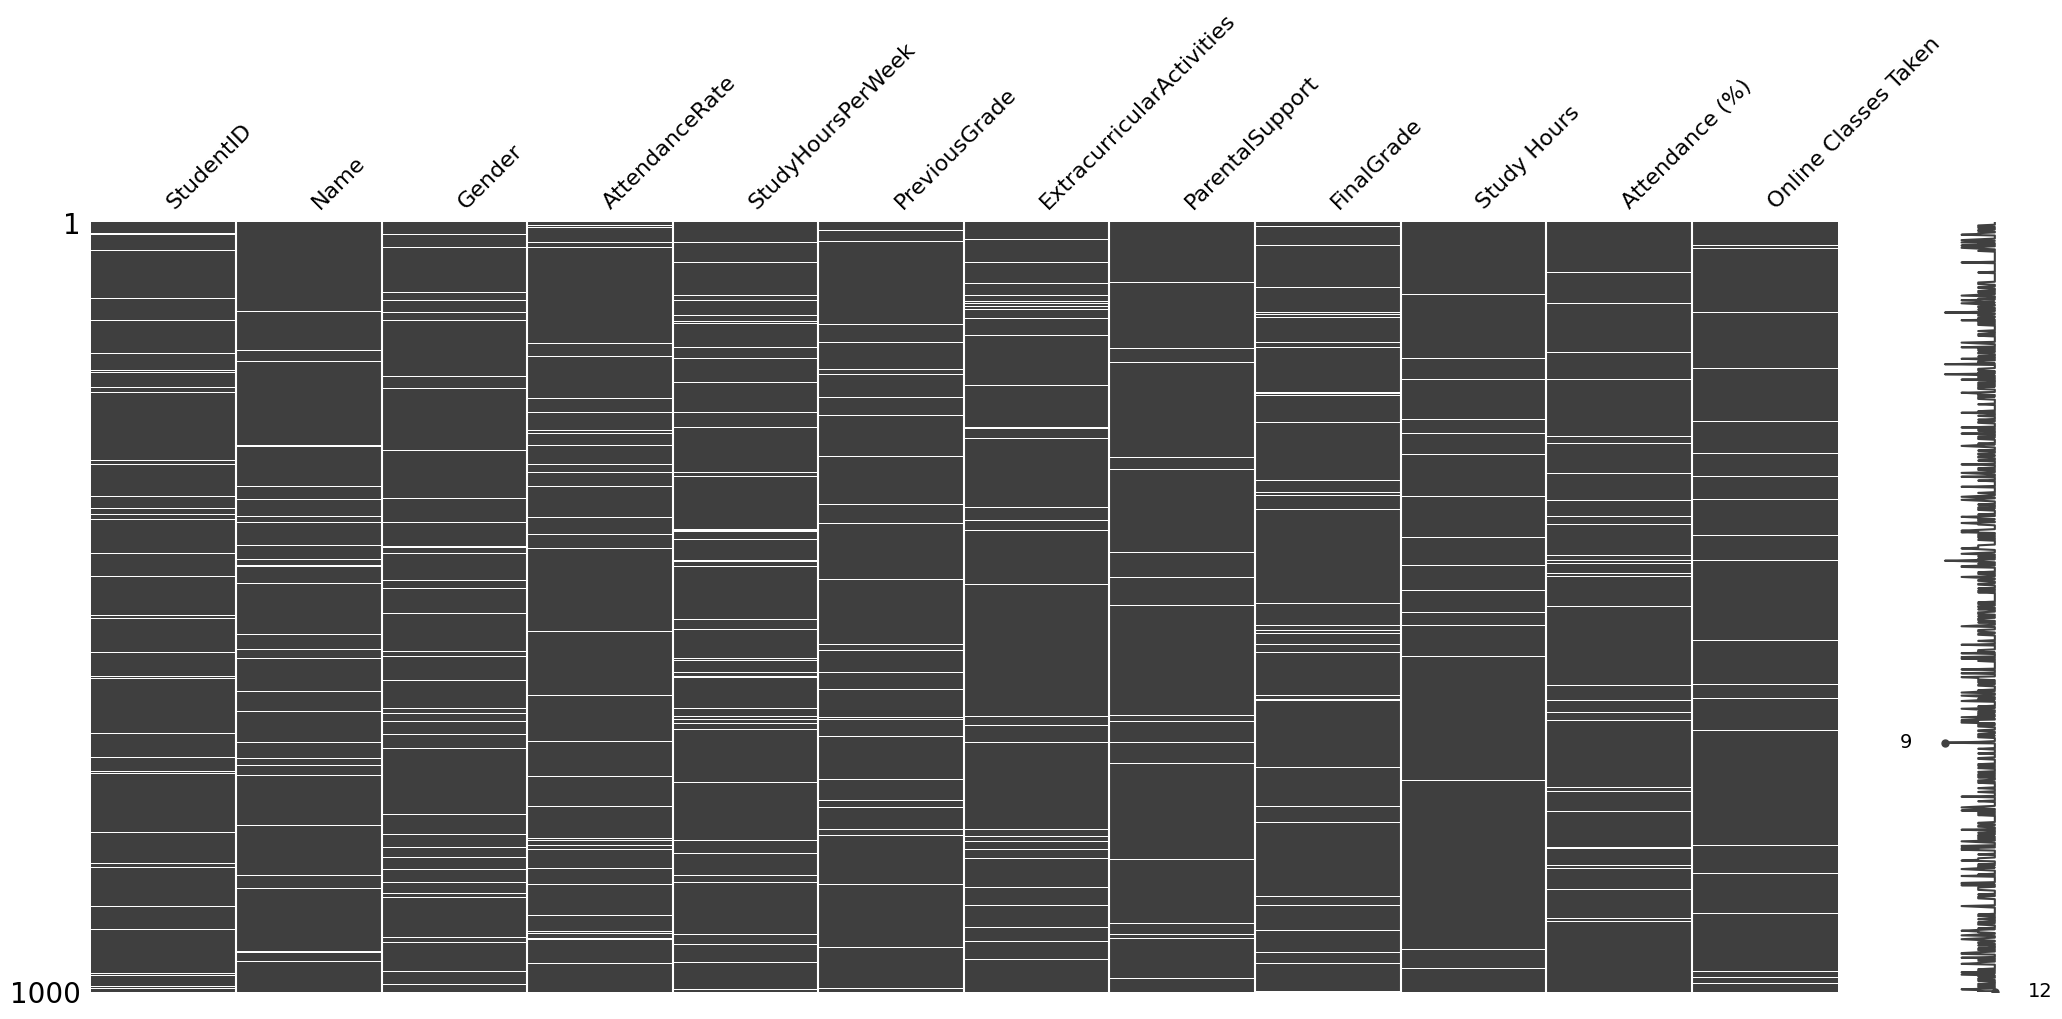

In [12]:
msno.matrix(df)

plt.savefig("Missing Values_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

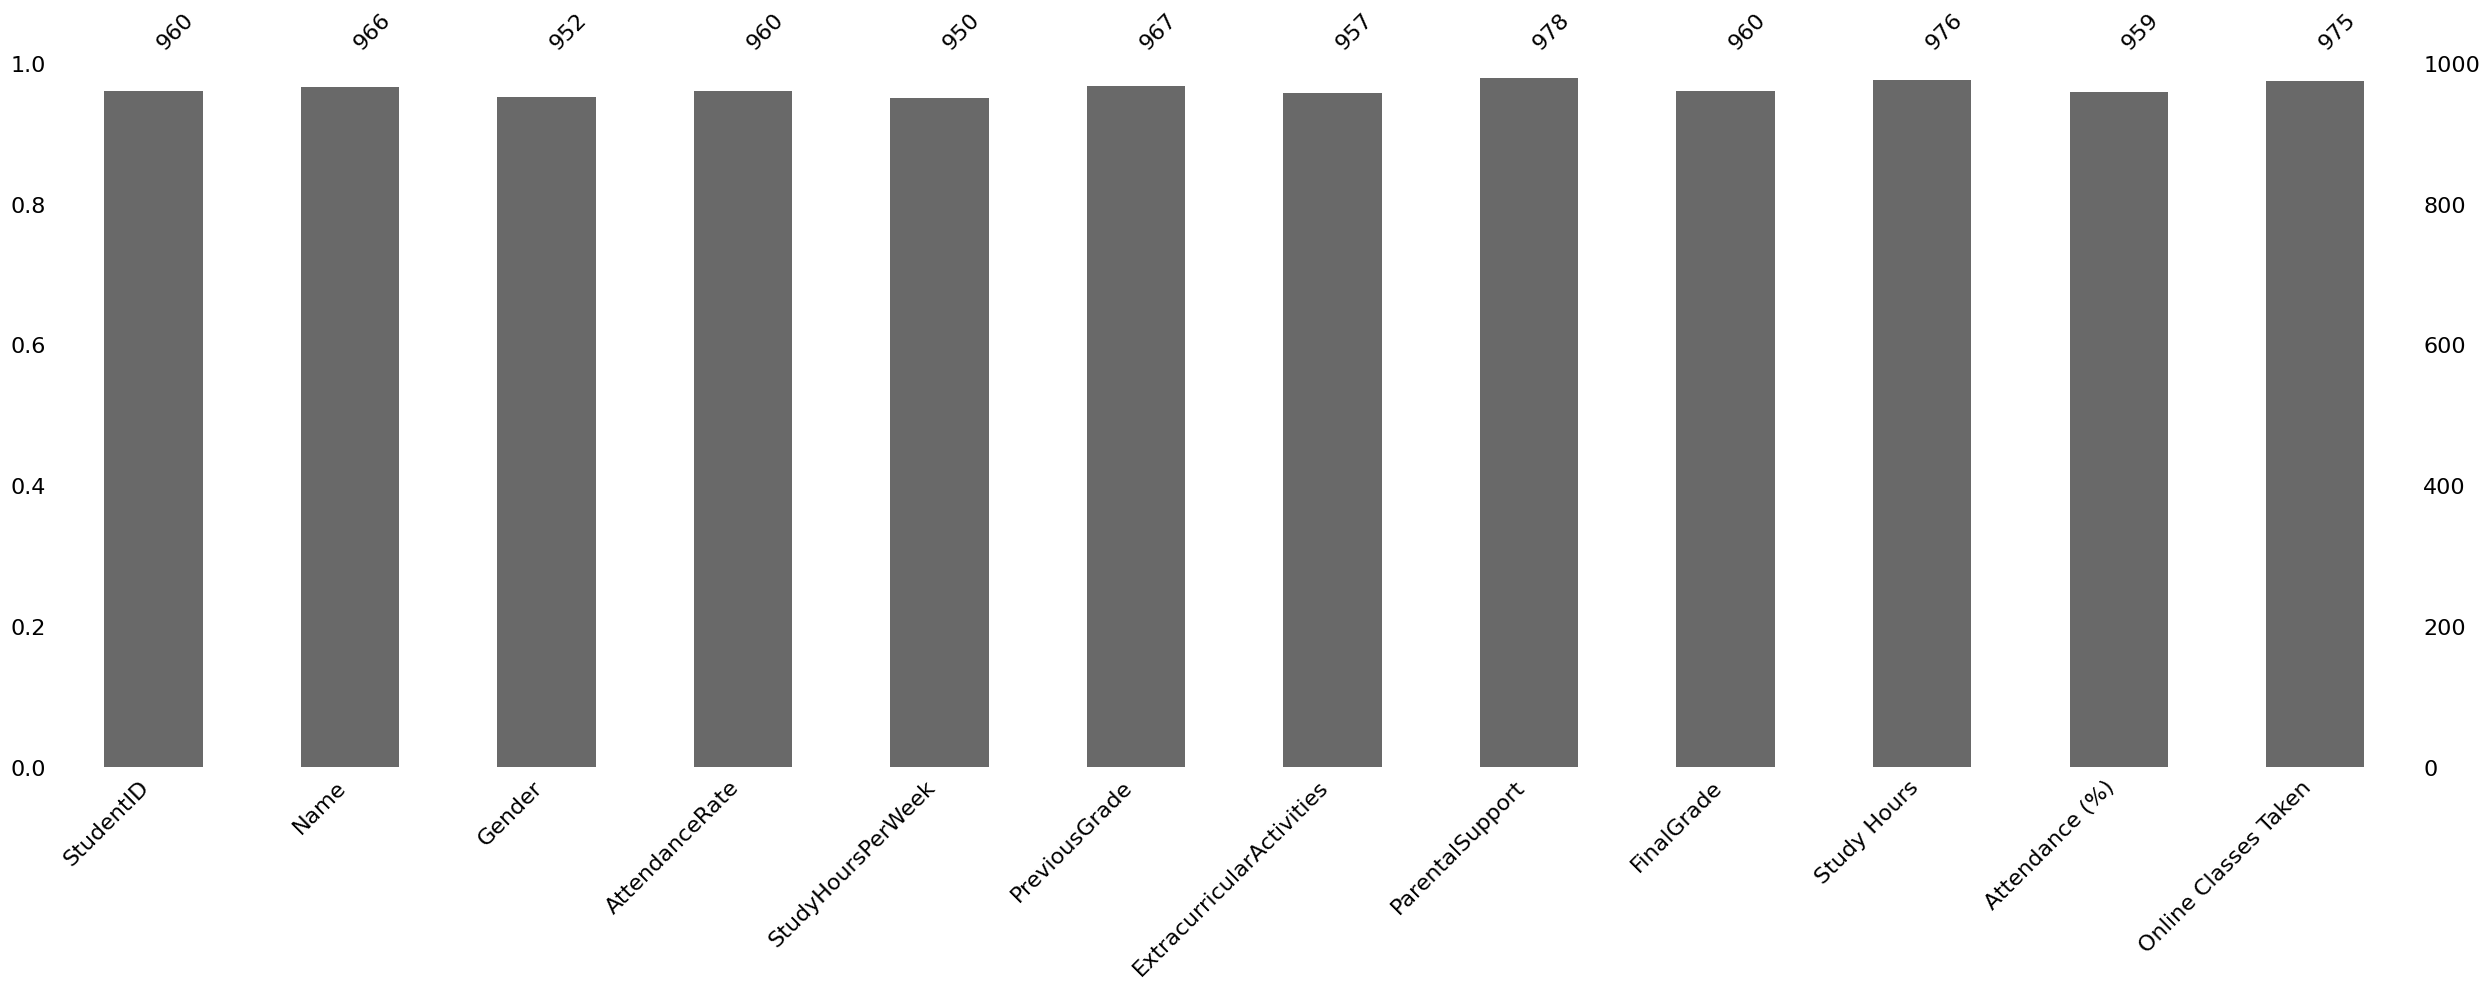

In [13]:
msno.bar(df)

plt.tight_layout()

plt.savefig(

   "images/Missing Values_bar.png",

    dpi=300

)

plt.show()

## Check Duplicate Rows

In [14]:
df.duplicated().sum()

np.int64(0)

## Data Types

In [15]:
df.dtypes

StudentID                    float64
Name                          object
Gender                        object
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport               object
FinalGrade                   float64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken          object
dtype: object

## Unique Values

In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

StudentID
[1.000e+00 2.000e+00 3.000e+00 4.000e+00 5.000e+00 6.000e+00 7.000e+00
 8.000e+00 9.000e+00 1.000e+01 2.824e+03 7.912e+03 4.611e+03 6.514e+03
       nan 2.139e+03 8.573e+03 5.386e+03 3.340e+03 6.930e+03 2.040e+03
 9.797e+03 9.201e+03 9.837e+03 1.949e+03 3.705e+03 8.177e+03 1.117e+03
 4.510e+03 6.804e+03 4.139e+03 2.604e+03 1.960e+03 3.536e+03 1.821e+03
 4.853e+03 1.152e+03 2.127e+03 5.905e+03 6.617e+03 1.058e+03 3.442e+03
 6.862e+03 3.900e+03 7.267e+03 1.387e+03 1.452e+03 8.149e+03 6.967e+03
 7.691e+03 5.930e+03 8.618e+03 2.530e+03 8.461e+03 2.746e+03 3.184e+03
 9.976e+03 4.919e+03 3.267e+03 7.812e+03 8.814e+03 4.595e+03 9.751e+03
 1.823e+03 7.906e+03 1.508e+03 8.619e+03 2.771e+03 2.669e+03 9.289e+03
 8.135e+03 6.280e+03 1.470e+03 1.166e+03 8.342e+03 8.753e+03 2.976e+03
 2.647e+03 1.745e+03 8.216e+03 3.485e+03 9.561e+03 4.404e+03 8.381e+03
 4.824e+03 2.169e+03 7.594e+03 5.102e+03 8.708e+03 7.690e+03 8.451e+03
 7.770e+03 9.998e+03 6.091e+03 9.165e+03 4.122e+03 9.022e+03 7.325e

## Data Cleaning

Handle missing values

In [17]:
df.fillna(df.median(numeric_only=True), inplace=True)

## Categorical columns

In [18]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

df["ParentalSupport"].fillna(df["ParentalSupport"].mode()[0], inplace=True)

## Univariate Analysis
Numerical Columns

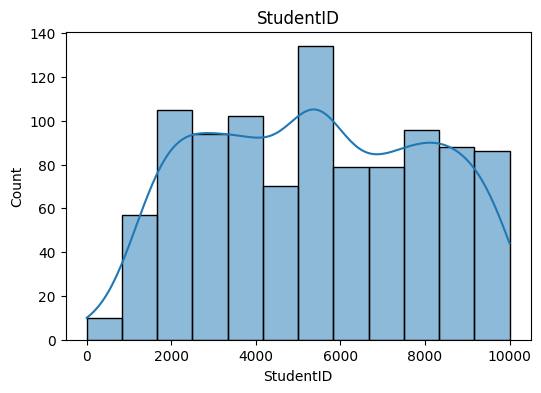

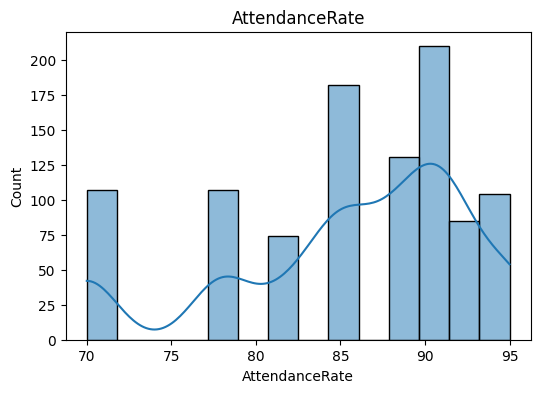

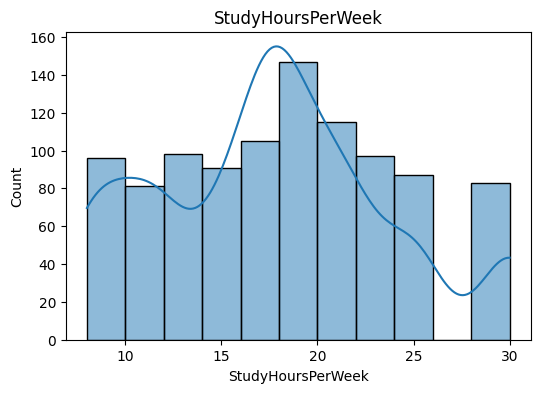

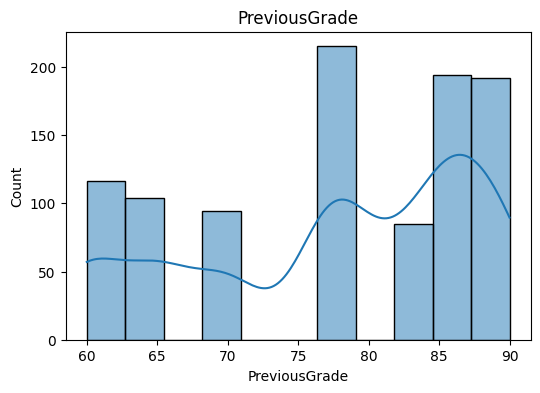

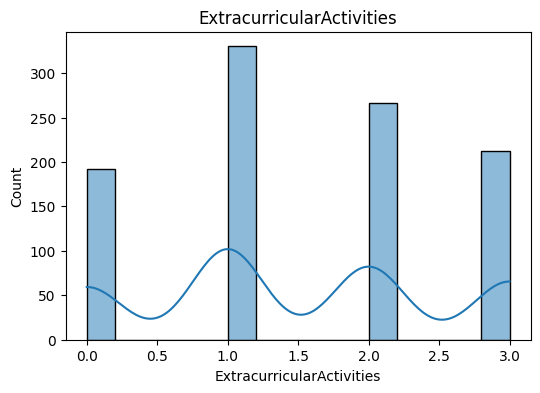

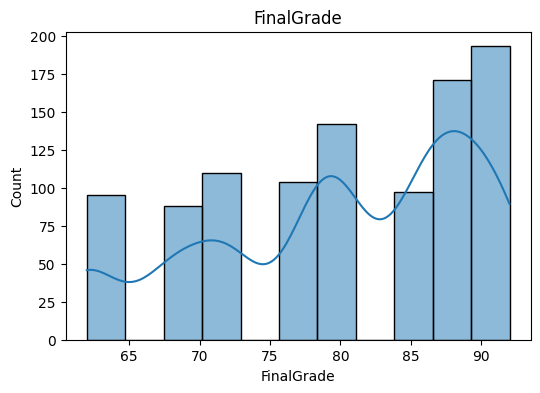

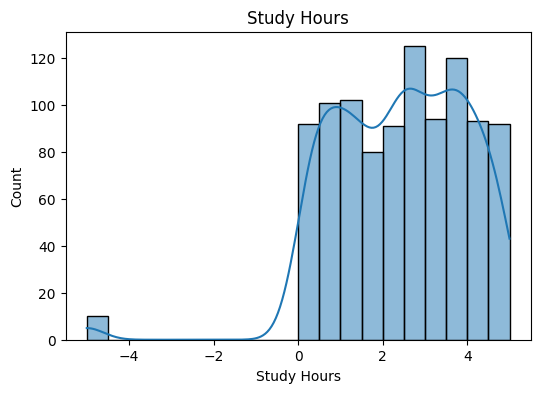

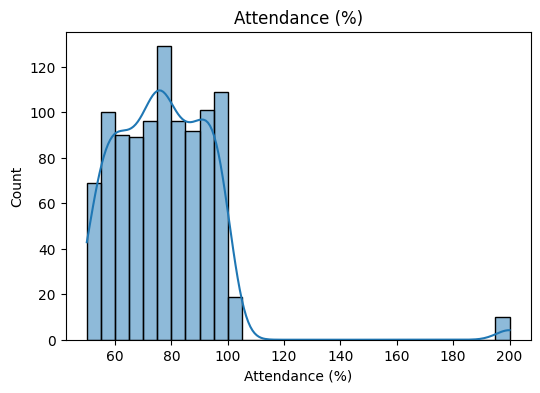

In [19]:
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],kde=True)

    plt.title(col)

    plt.show()

## Boxplots

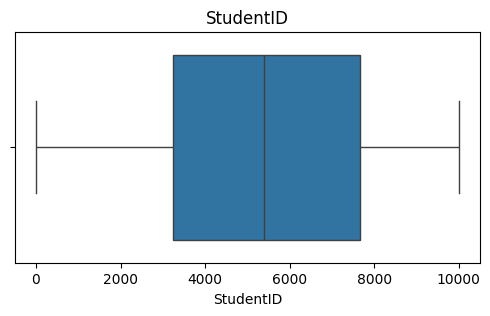

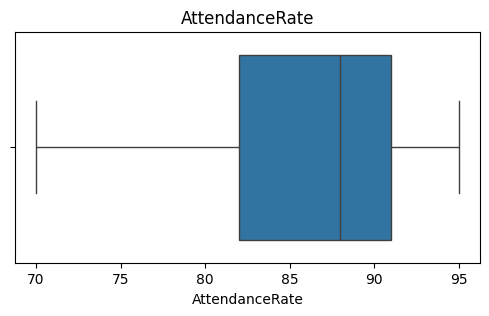

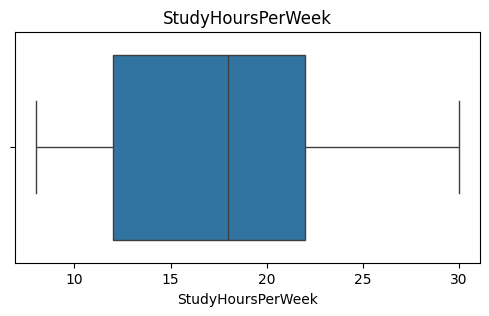

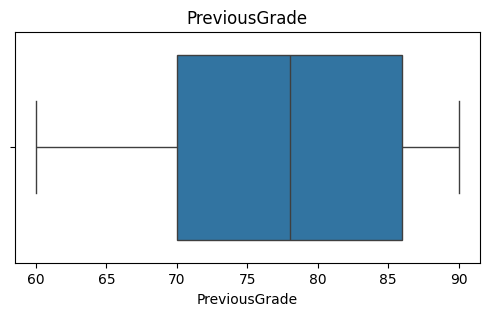

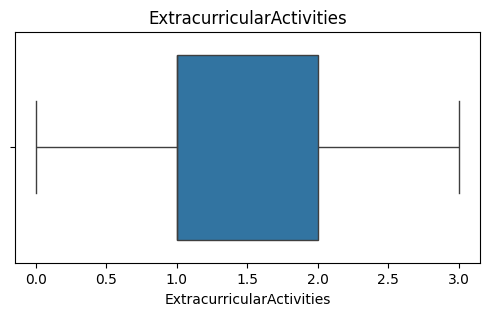

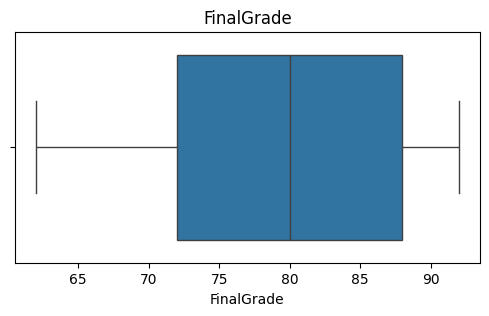

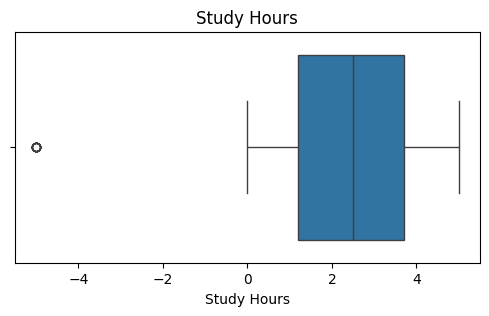

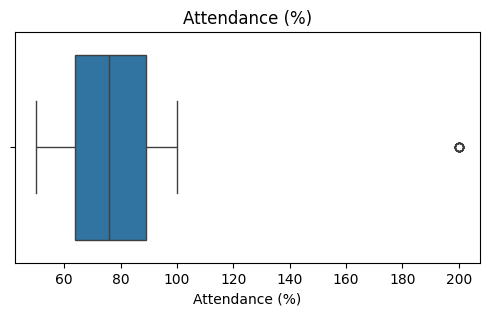

In [20]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

## Categorical

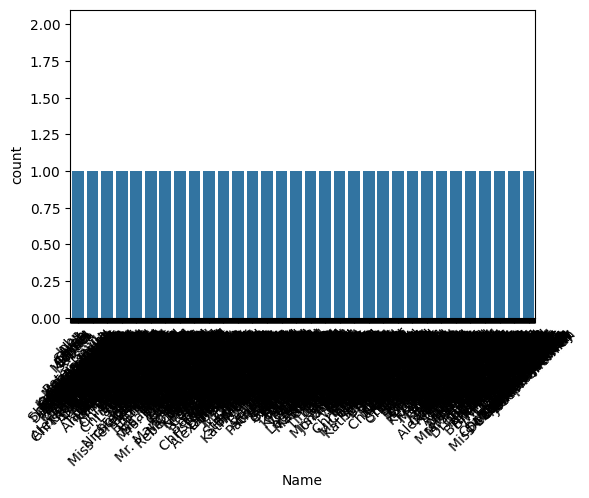

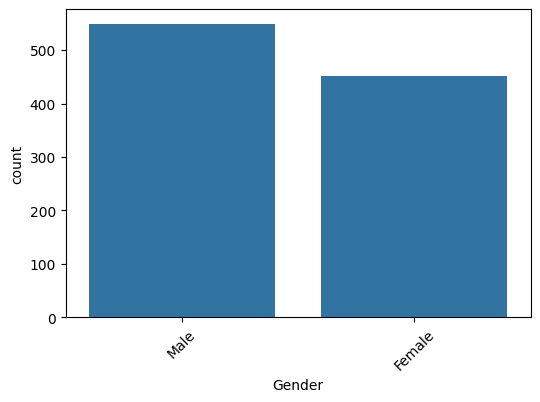

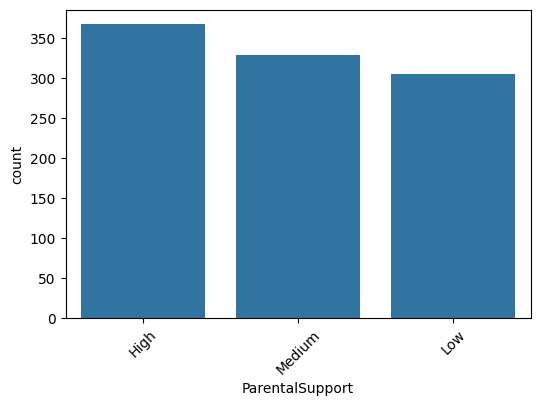

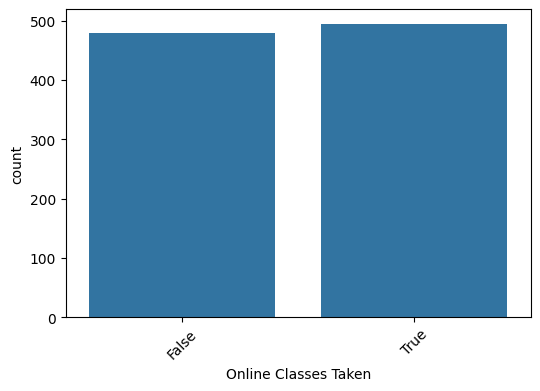

In [21]:
cat_cols=df.select_dtypes(include=['object','bool']).columns

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df,x=col)

    plt.xticks(rotation=45)

    plt.show()

## Bivariate Analysis
Numerical vs FinalGrade

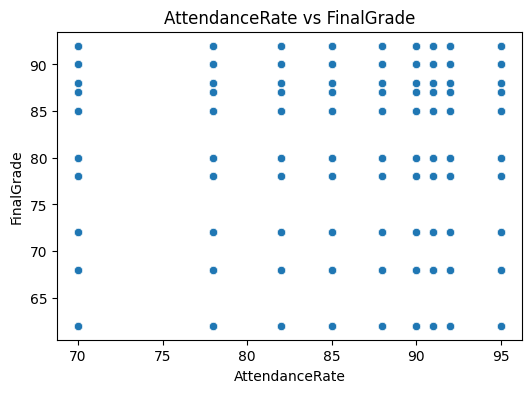

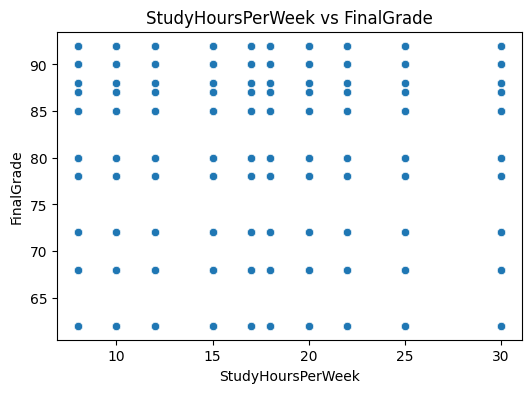

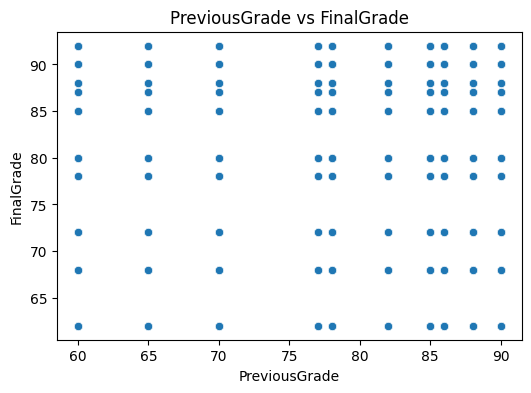

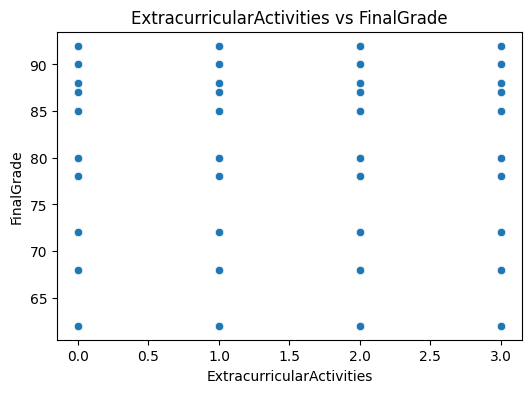

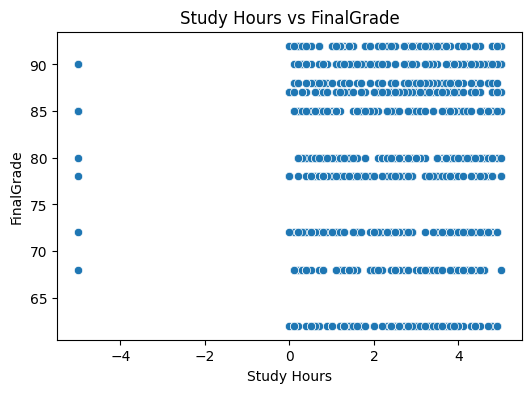

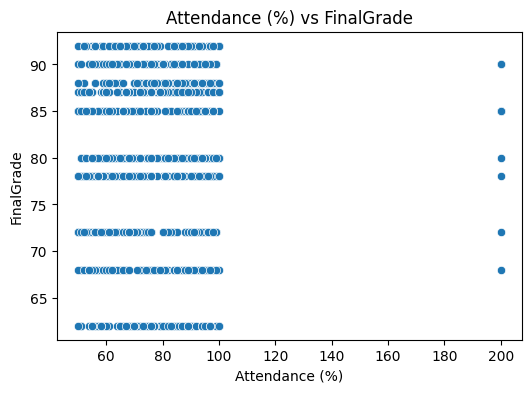

In [22]:
features=['AttendanceRate',
'StudyHoursPerWeek',
'PreviousGrade',
'ExtracurricularActivities',
'Study Hours',
'Attendance (%)']

for col in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(data=df,
                    x=col,
                    y='FinalGrade')

    plt.title(f'{col} vs FinalGrade')

    plt.show()

## Categorical vs FinalGrade

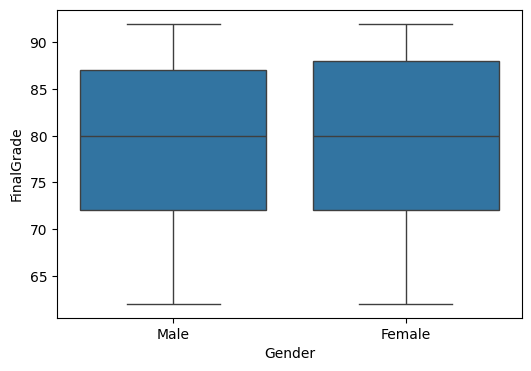

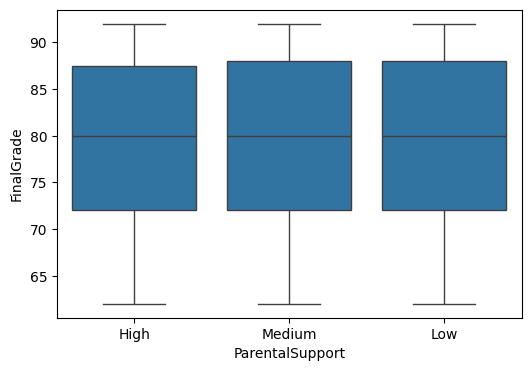

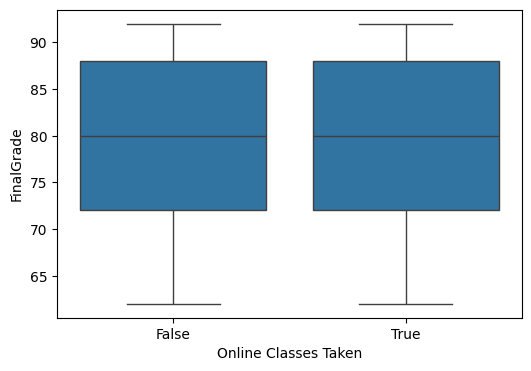

In [23]:
cats=['Gender',
'ParentalSupport',
'Online Classes Taken']

for col in cats:

    plt.figure(figsize=(6,4))

    sns.boxplot(data=df,
                x=col,
                y='FinalGrade')

    plt.show()

## Correlation

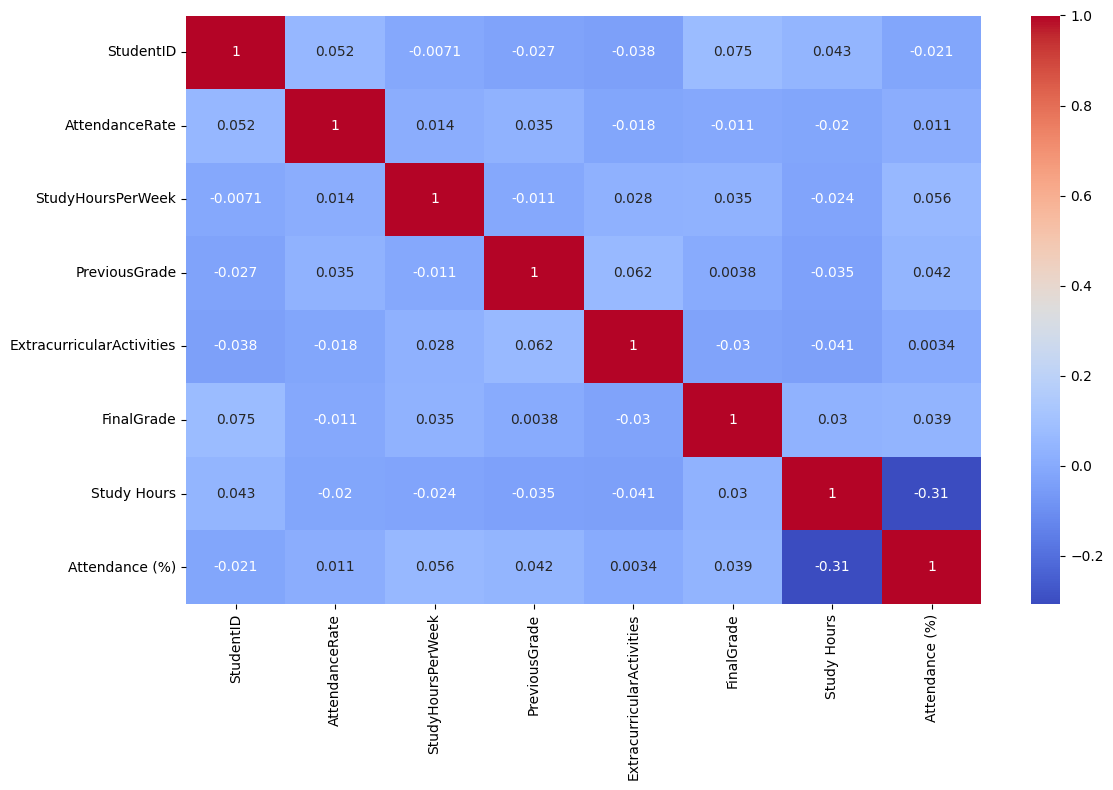

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.tight_layout()

plt.savefig(

    "images/correlation_heatmap.png",

    dpi=300

)


plt.show()

## Feature Engineering

Drop unnecessary columns

In [25]:
df.drop(['Name'],axis=1,inplace=True)

## Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include=['object','bool']).columns:

    df[col]=encoder.fit_transform(df[col])

## Feature Selection

In [27]:
X=df.drop('FinalGrade',axis=1)

y=df['FinalGrade']

## Train Test Split

In [28]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

## Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

## Linear Regression

In [30]:
model=LinearRegression()

model.fit(X_train,y_train)

pred=model.predict(X_test)

## Evaluation

In [31]:
print("MAE :",mean_absolute_error(y_test,pred))

print("MSE :",mean_squared_error(y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

print("R2 :",r2_score(y_test,pred))

MAE : 8.019003118298249
MSE : 89.6970720148116
RMSE : 9.470853816568578
R2 : 0.0010836200506812999


## Actual vs Predicted

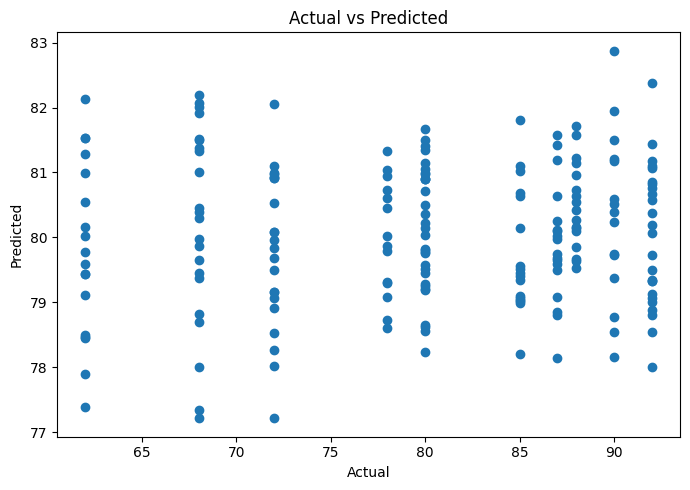

In [32]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")
plt.tight_layout()

plt.savefig(

    "images/Actual vs Predicted_scatter.png",

    dpi=300

)

plt.show()

## Feature Importance

In [33]:
coef=pd.DataFrame({

'Feature':X.columns,

'Coefficient':model.coef_

})

coef=coef.sort_values(by='Coefficient',key=abs,ascending=False)

print(coef)

                     Feature  Coefficient
1                     Gender    -0.634346
8             Attendance (%)     0.608689
0                  StudentID     0.507999
7                Study Hours     0.435847
6            ParentalSupport     0.368466
3          StudyHoursPerWeek     0.349017
9       Online Classes Taken     0.274735
5  ExtracurricularActivities    -0.206617
2             AttendanceRate    -0.098843
4              PreviousGrade     0.083662


## Save Clean Dataset

In [34]:
df.to_csv("Cleaned_StudentPerformance.csv",index=False)

## Save Correlation Matrix

In [35]:
corr=df.corr(numeric_only=True)

corr.to_csv("Correlation.csv")

## Save Prediction

In [36]:
prediction=pd.DataFrame({

'Actual':y_test,

'Prediction':pred

})

prediction.to_csv("Prediction.csv",index=False)

## Create Models

In [37]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.1),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )

}

## Train Every Model

Linear Regression
MAE : 8.019003118298249
MSE : 89.6970720148116
RMSE : 9.470853816568578
R2 : 0.0010836200506812999


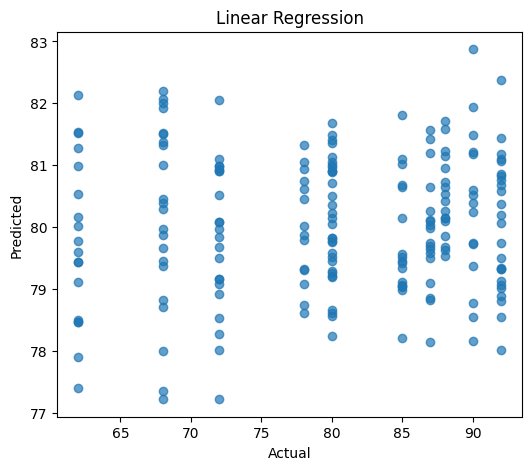

Ridge Regression
MAE : 8.018895796344381
MSE : 89.69534734922462
RMSE : 9.470762764910999
R2 : 0.0011028268839265998


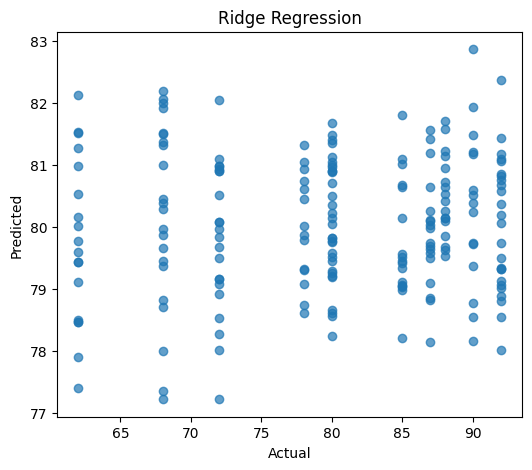

Lasso Regression
MAE : 8.00158175416277
MSE : 89.55502747964724
RMSE : 9.463351809990328
R2 : 0.002665506835509146


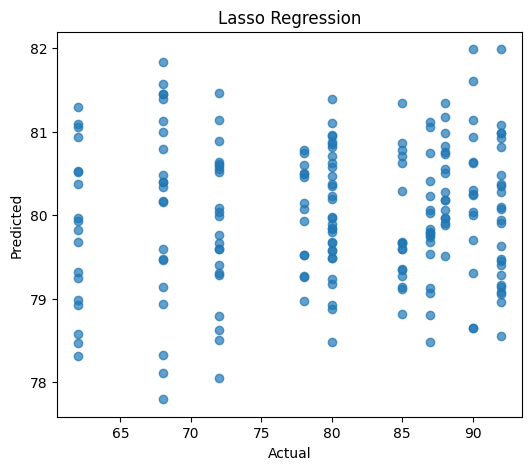

Decision Tree
MAE : 10.515
MSE : 184.425
RMSE : 13.580316638429313
R2 : -1.0538591643407509


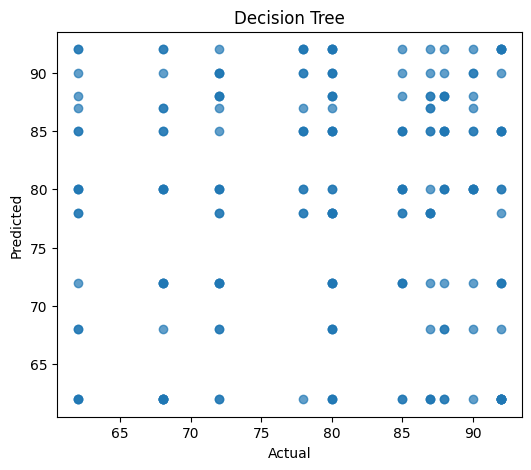

Random Forest
MAE : 7.973899999999999
MSE : 88.38196399999998
RMSE : 9.401168225279239
R2 : 0.015729392848939705


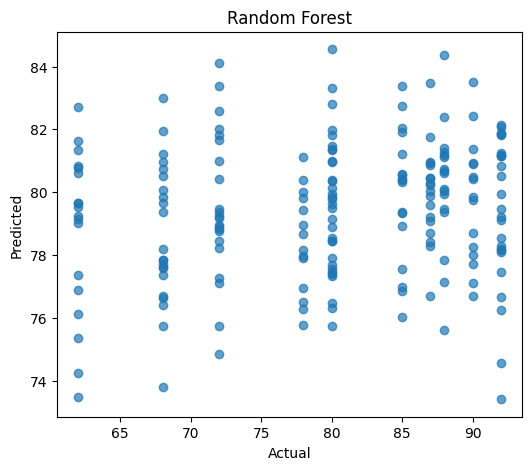

AdaBoost
MAE : 8.297386783229424
MSE : 93.63408531527739
RMSE : 9.676470705545354
R2 : -0.04276114528641006


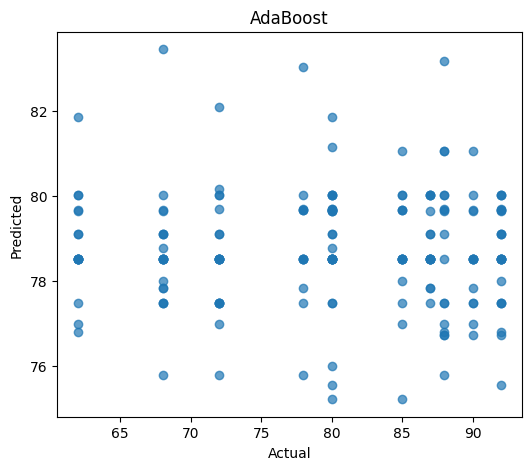

Gradient Boosting
MAE : 8.116869516281028
MSE : 91.86832183142288
RMSE : 9.584796389669572
R2 : -0.02309662305041793


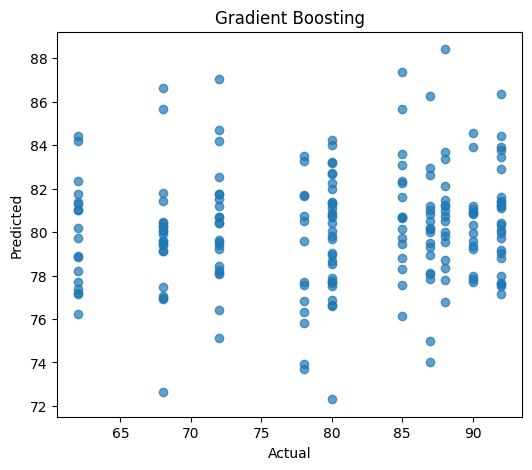

XGBoost
MAE : 8.980532779693604
MSE : 117.4708790040695
RMSE : 10.838398359724074
R2 : -0.3082209103194884


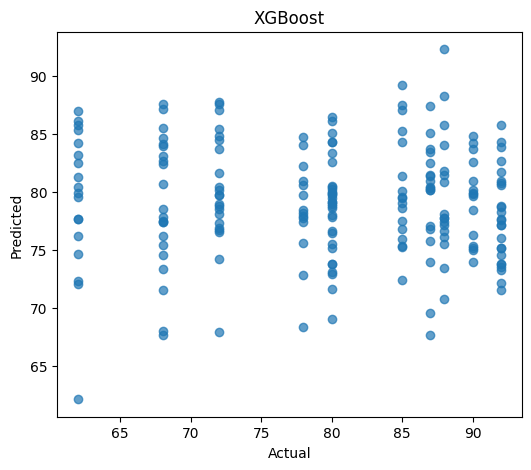

In [38]:
for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 :", r2)

    if "results" not in globals():
        results = []

    results.append({

        "Model": name,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2 Score": r2

    })

    # Scatter Plot

    plt.figure(figsize=(6,5))

    plt.scatter(y_test, pred, alpha=0.7)

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(name)

    os.makedirs("Plots/Regression", exist_ok=True)
    plt.savefig(
        f"Plots/Regression/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## omparison Table

In [39]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

               Model        MAE         MSE       RMSE  R2 Score
4      Random Forest   7.973900   88.381964   9.401168  0.015729
2   Lasso Regression   8.001582   89.555027   9.463352  0.002666
1   Ridge Regression   8.018896   89.695347   9.470763  0.001103
0  Linear Regression   8.019003   89.697072   9.470854  0.001084
6  Gradient Boosting   8.116870   91.868322   9.584796 -0.023097
5           AdaBoost   8.297387   93.634085   9.676471 -0.042761
7            XGBoost   8.980533  117.470879  10.838398 -0.308221
3      Decision Tree  10.515000  184.425000  13.580317 -1.053859


## Save Comparison Table

In [40]:
results_df.to_csv(
    "Regression_Results.csv",
    index=False
)

## Save Excel File

In [41]:
results_df.to_excel(
    "Regression_Results.xlsx",
    index=False
)

## Plot Model Comparison

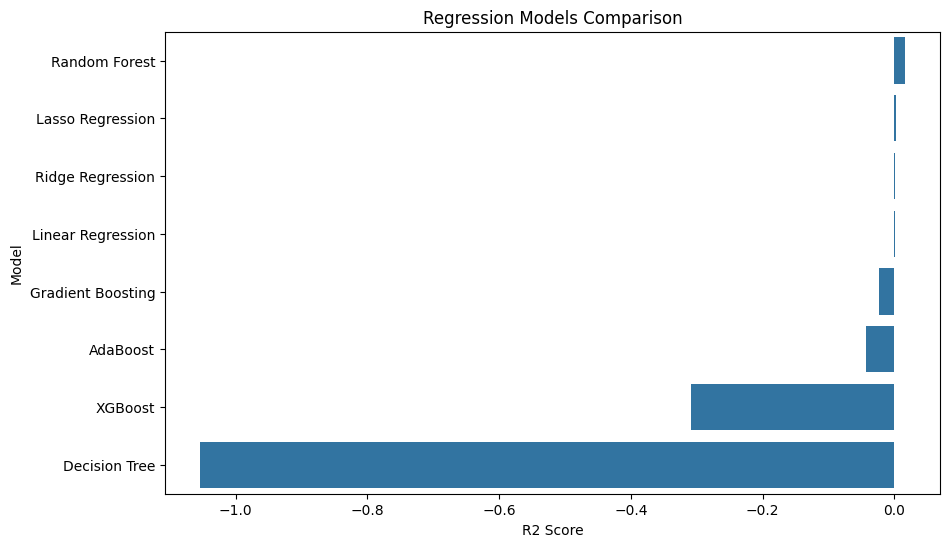

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Regression Models Comparison")

plt.savefig(
    "Plots/Regression/Regression_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## Save Best Model

In [43]:
import joblib

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(
    best_model,
    "Best_Regression_Model.pkl"
)

print("Best Model:", best_model_name)

Best Model: Random Forest
